### Importing Relevant libraries

In [1]:
import numpy as np
import pandas as pd
import sqlite3 as sql
import seaborn as sns
import matplotlib.pyplot as plt

### Generation trends NITI

In [2]:
gen_df = pd.read_csv('../data/raw/niti_aayog/solar-gen-trends-15to26.csv')
gen_df = gen_df[gen_df['year']!= '2026-27']
gen_df.head()

,source,state,generation,year,month
0,solar,Andaman and Nicobar Islands,1.17,2015-16,April
1,solar,Andaman and Nicobar Islands,0.83,2015-16,August
2,solar,Andaman and Nicobar Islands,0.84,2015-16,December
3,solar,Andaman and Nicobar Islands,1.37,2015-16,February
4,solar,Andaman and Nicobar Islands,1.35,2015-16,January


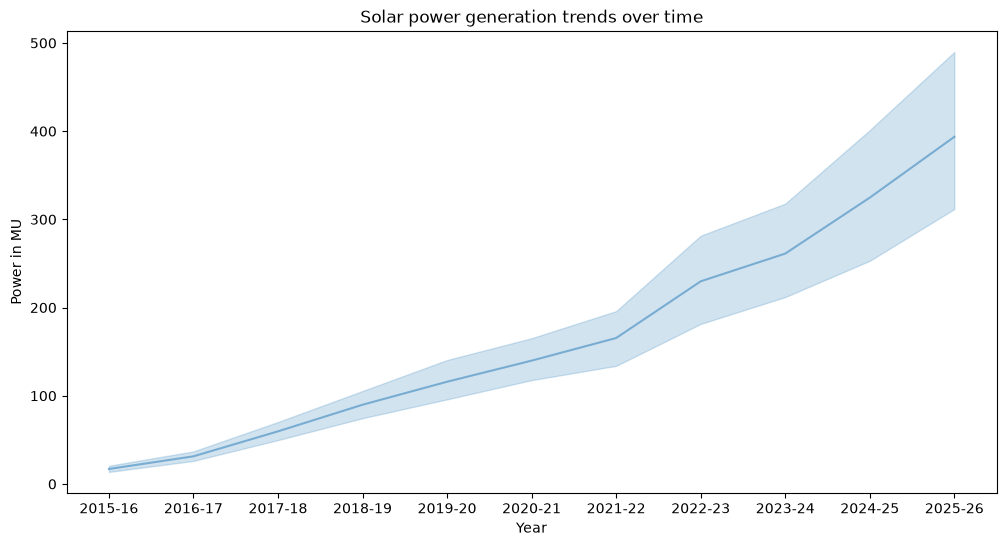

In [3]:
plt.figure(figsize=(12,6))
sns.lineplot(x=gen_df['year'], y=gen_df['generation'], alpha=0.5)
plt.title('Solar power generation trends over time')
plt.xlabel('Year')
plt.ylabel('Power in MU')
plt.show()

### Installed Capacity Trends NITI

In [4]:
cap_df = pd.read_csv('../data/raw/niti_aayog/solar-installed-capacity-trends-15to26.csv')
cap_df = cap_df[cap_df['fyear']!='2026-27']
cap_df.head()

,state,fyear,source,capacity
0,Andaman and Nicobar Islands,2015-16,solar,5.34
1,Andaman and Nicobar Islands,2016-17,solar,6.80
2,Andaman and Nicobar Islands,2017-18,solar,6.80
3,Andaman and Nicobar Islands,2018-19,solar,11.97
4,Andaman and Nicobar Islands,2019-20,solar,12.43


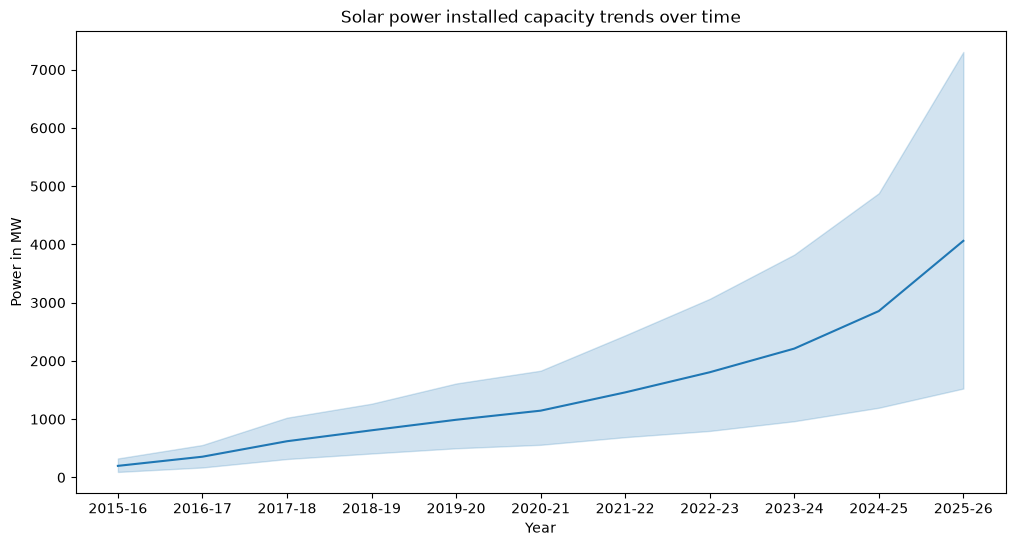

In [5]:
plt.figure(figsize=(12,6))
sns.lineplot(x=cap_df.fyear, y=cap_df.capacity)
plt.title('Solar power installed capacity trends over time')
plt.xlabel('Year')
plt.ylabel('Power in MW')
plt.show()

#### Demand Trends CEA

In [6]:
demand_df = pd.read_csv("../data/raw/cea/cea_csv/cea_monthly_peak_demand.csv")
demand_df = demand_df[demand_df['year']!=2026]
demand_df = demand_df.drop(columns=['source_file'])
demand_df

,state,year,month,peak_demand_mw,peak_met_mw
0,Andhra Pradesh,2015,1,6397.0,6392.0
1,Andhra Pradesh,2015,2,6530.0,6518.0
2,Andhra Pradesh,2015,3,6790.0,6784.0
3,Andhra Pradesh,2015,4,6794.0,6789.0
4,Andhra Pradesh,2015,5,6737.0,6732.0
...,...,...,...,...,...
4871,West Bengal,2025,8,11451.0,11451.0
4872,West Bengal,2025,9,11868.0,11868.0
4873,West Bengal,2025,10,10283.0,10283.0
4874,West Bengal,2025,11,9070.0,9069.0


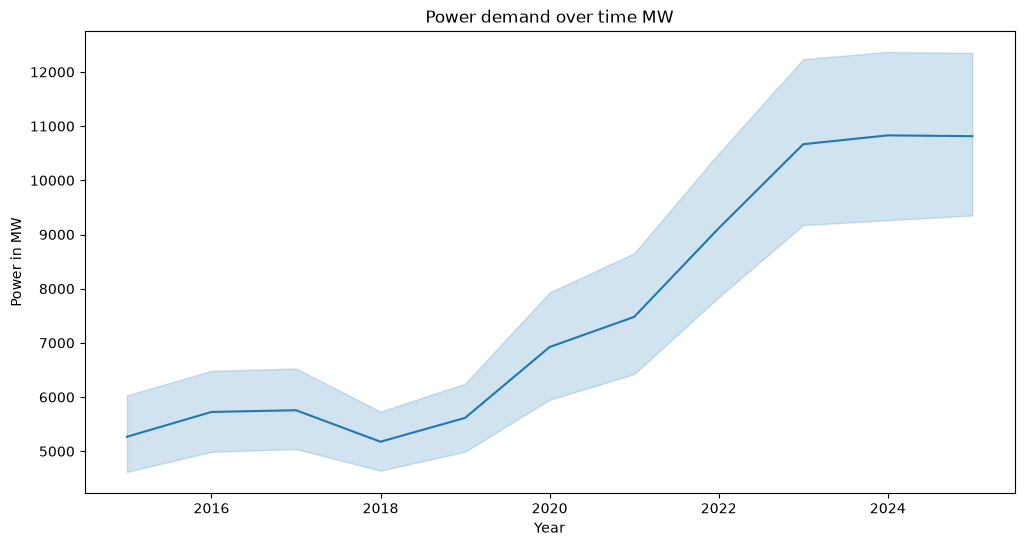

In [7]:
plt.figure(figsize=(12,6))
sns.lineplot(x=demand_df.year, y=demand_df.peak_demand_mw)
plt.title('Power demand over time MW')
plt.xlabel('Year')
plt.ylabel('Power in MW')
plt.show()

#### Standardizing year into fyear

In [8]:
def get_fyear(row):
    year = int(row['year'])
    month = int(row['month'])

    if month >= 4:
        return f"{year}-{str(year+1)[-2:]}"
    else:
        return f"{year-1}-{str(year)[-2:]}"

demand_df["year"] = demand_df.apply(get_fyear, axis=1)
demand_df 

,state,year,month,peak_demand_mw,peak_met_mw
0,Andhra Pradesh,2014-15,1,6397.0,6392.0
1,Andhra Pradesh,2014-15,2,6530.0,6518.0
2,Andhra Pradesh,2014-15,3,6790.0,6784.0
3,Andhra Pradesh,2015-16,4,6794.0,6789.0
4,Andhra Pradesh,2015-16,5,6737.0,6732.0
...,...,...,...,...,...
4871,West Bengal,2025-26,8,11451.0,11451.0
4872,West Bengal,2025-26,9,11868.0,11868.0
4873,West Bengal,2025-26,10,10283.0,10283.0
4874,West Bengal,2025-26,11,9070.0,9069.0


#### Standardizing naming and order of features

In [9]:
# Adding a month_name col if month_num exists and vice versa
def month_mapping(df, month):
    month_name_to_num = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
    }

    month_num_to_name = {v: k for k,v in month_name_to_num.items()}

    if df[month].dtype == 'int':
        df["month_name"] = df[month].map(month_num_to_name)
        df = df.rename(columns={'month': 'month_num'})
    elif df[month].dtype == 'str':
        df['month_num'] = df[month].map(month_name_to_num)
        df = df.rename(columns={'month':'month_name'})
    return df


gen_df = month_mapping(gen_df, 'month')
demand_df = month_mapping(demand_df, 'month')

In [10]:
# Renaming the targetskk to include units and also ensuring similar order
gen_df = gen_df.rename(columns={'year':'fyear', 'generation':'generation_mu'})
gen_df = gen_df[['state', 'fyear', 'month_num', 'month_name', 'generation_mu']]
cap_df = cap_df.rename(columns={'capacity':'capacity_mw'})
cap_df = cap_df[['state', 'fyear', 'capacity_mw']]
demand_df = demand_df.rename(columns={'year':'fyear'})
demand_df = demand_df[['state', 'fyear', 'month_num', 'month_name', 'peak_demand_mw']]

In [11]:
print(gen_df.columns)
print(cap_df.columns)
print(demand_df.columns)

Index(['state', 'fyear', 'month_num', 'month_name', 'generation_mu'], dtype='str')
Index(['state', 'fyear', 'capacity_mw'], dtype='str')
Index(['state', 'fyear', 'month_num', 'month_name', 'peak_demand_mw'], dtype='str')


### Write to SQL and index

In [12]:
with sql.connect('../data/processed/energy-masterdb.sqlite') as conn:
    cur = conn.cursor()

    gen_df.to_sql('generation', conn, if_exists='replace', index=False)
    cap_df.to_sql('capacity', conn, if_exists='replace', index=False)
    demand_df.to_sql('demand', conn, if_exists='replace', index=False)


    cur.executescript('''
    CREATE INDEX IF NOT EXISTS idx_gen ON generation(state, fyear, month_num);
    CREATE INDEX IF NOT EXISTS idx_cap ON capacity(state, fyear);
    CREATE INDEX IF NOT EXISTS idx_demand ON demand(state, fyear, month_num);
    ''')

    conn.commit()

In [13]:
with sql.connect('../data/processed/energy-masterdb.sqlite') as conn:
    cur = conn.cursor()
    demand = pd.read_sql_query('select * from demand', conn)
    demand_indexes = pd.read_sql_query("PRAGMA index_list('demand')", conn)

In [14]:
query = '''
SELECT 
    g.state,
    g.fyear,
    g.month_name,
    g.generation_mu AS solar_gen_mu,
    c.capacity_mw AS installed_capacity_mw,
    d.peak_demand_mw
FROM generation g
LEFT JOIN capacity c 
    ON g.state = c.state AND g.fyear = c.fyear
LEFT JOIN demand d 
    ON g.state = d.state AND g.fyear = d.fyear AND g.month_name = d.month_name
'''

with sql.connect('../data/processed/energy-masterdb.sqlite') as conn:
    cur = conn.cursor()
    master_df = pd.read_sql_query(query, conn)

In [15]:
master_df

,state,fyear,month_name,solar_gen_mu,installed_capacity_mw,peak_demand_mw
0,Andaman and Nicobar Islands,2015-16,April,1.17,5.34,NaN
1,Andaman and Nicobar Islands,2015-16,August,0.83,5.34,NaN
2,Andaman and Nicobar Islands,2015-16,December,0.84,5.34,NaN
3,Andaman and Nicobar Islands,2015-16,February,1.37,5.34,NaN
4,Andaman and Nicobar Islands,2015-16,January,1.35,5.34,NaN
...,...,...,...,...,...,...
4807,West Bengal,2025-26,March,41.38,320.62,NaN
4808,West Bengal,2025-26,May,40.31,320.62,12693.0
4809,West Bengal,2025-26,November,35.34,320.62,9070.0
4810,West Bengal,2025-26,October,32.25,320.62,10283.0
